## Hands-on 3
#### Six stages of machine learning workflow.
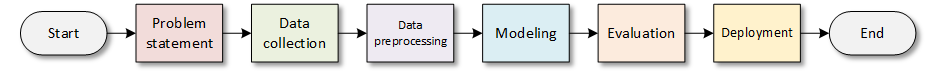

In [ ]:
# Initialization
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the required libraries
import numpy as np
from pandas import read_csv
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

### Stage 1 Problem statement
- To predict the gender based on height and weight

### Stage 2 Data collection
- Collect the required data to solve the problem

In [ ]:
# load dataset
df = read_csv("https://raw.githubusercontent.com/wooihaw/ai_with_python_2024/main/heights_weights_genders.csv")

# Check the data
print(f"Dimension of the data: {df.shape}")

# Select 5 data samples random and print them
df.sample(5)

In [ ]:
# Exploratory data analysis
mpos = df['Gender'] == 'Male'
fpos = df['Gender'] == 'Female'
plt.plot(df[mpos]['Height(cm)'], df[mpos]['Weight(kg)'], 'b*', alpha=0.1, label='Male')
plt.plot(df[fpos]['Height(cm)'], df[fpos]['Weight(kg)'], 'ro', alpha=0.1, label='Female')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend(loc='best')
plt.show()

### Stage 3 Data preprocessing
- Prepare the data in the appropriate format and structure

In [ ]:
# Seperate the dataset into features (X) and label (y)
X = df.drop(columns=['Gender'])
y = df['Gender']
print(f'X dimension: {X.shape}')
print(f'y dimension: {y.shape}')

In [ ]:
# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'X_train dimension: {X_train.shape}')
print(f'X_test dimension: {X_test.shape}')
print(f'y_train dimension: {y_train.shape}')
print(f'y_test dimension: {y_test.shape}')

### Stage 4 Modeling
- Build the model to solve the problem

In [ ]:
# KNN classifier
knn = KNeighborsClassifier().fit(X_train, y_train)

### Stage 5 Evaluation
- Evaluate the performe of the model

In [ ]:
print(f'KNN accuracy: {knn.score(X_test, y_test):.2%}')

### Stage 6 Deployment
- Deploy the model for problem solving

In [ ]:
# Make prediction based on user input
try:
    h = float(input('Please enter height (cm): '))
    w = float(input('Please enter weight (kg): '))
    assert 0 < h < 300 and 0 < w < 300, "Value out of range"
except ValueError:
    print("Invalid input! Please only enter number")
except AssertionError as e:
    print("Error! ", e)
else:
    res1 = knn.predict([[h, w]])
    print(f'kNN predicts: {res1}')